# BDD100K EDA

In [ ]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import cv2

DATA = Path("../data")

CLASS_NAMES = {
    0: "car", 1: "person", 2: "traffic sign", 3: "traffic light",
    4: "truck", 5: "bus", 6: "bike", 7: "rider", 8: "motor", 9: "train"
}

SPLITS = {
    "clear_day/train": "Train (clear/day)",
    "clear_day/val": "Val (clear/day)",
    "rainy": "Rainy",
    "snowy": "Snowy",
    "night": "Night",
    "overcast": "Overcast",
}

In [ ]:
def load_labels(split):
    """Load all YOLO labels for a split. Returns list of (class_id, cx, cy, w, h)."""
    label_dir = DATA / split / "labels"
    boxes = []
    obj_counts = []
    for f in sorted(label_dir.glob("*.txt")):
        img_boxes = []
        for line in f.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) == 5:
                img_boxes.append([int(parts[0])] + [float(x) for x in parts[1:]])
        boxes.extend(img_boxes)
        obj_counts.append(len(img_boxes))
    return np.array(boxes) if boxes else np.zeros((0, 5)), obj_counts

## Split sizes

Train (clear/day)          12477 images
Val (clear/day)             1764 images
Rainy                       1306 images
Snowy                       1551 images
Night                       8036 images
Overcast                    2568 images


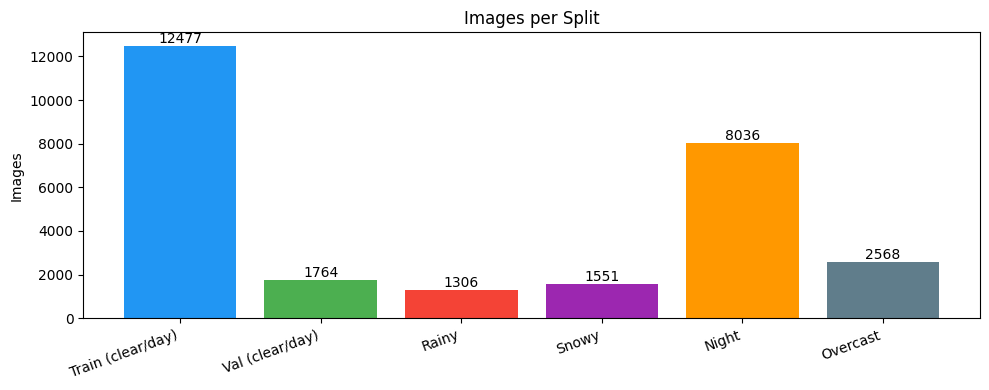

In [ ]:
split_counts = {}
for split, label in SPLITS.items():
    n_imgs = len(list((DATA / split / "images").glob("*.jpg")))
    split_counts[label] = n_imgs
    print(f"{label:<25} {n_imgs:>6} images")

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(split_counts.keys(), split_counts.values(), color=["#2196F3", "#4CAF50", "#F44336", "#9C27B0", "#FF9800", "#607D8B"])
ax.bar_label(bars)
ax.set_ylabel("Images")
ax.set_title("Images per Split")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Class distribution (training set)

Total boxes: 240141


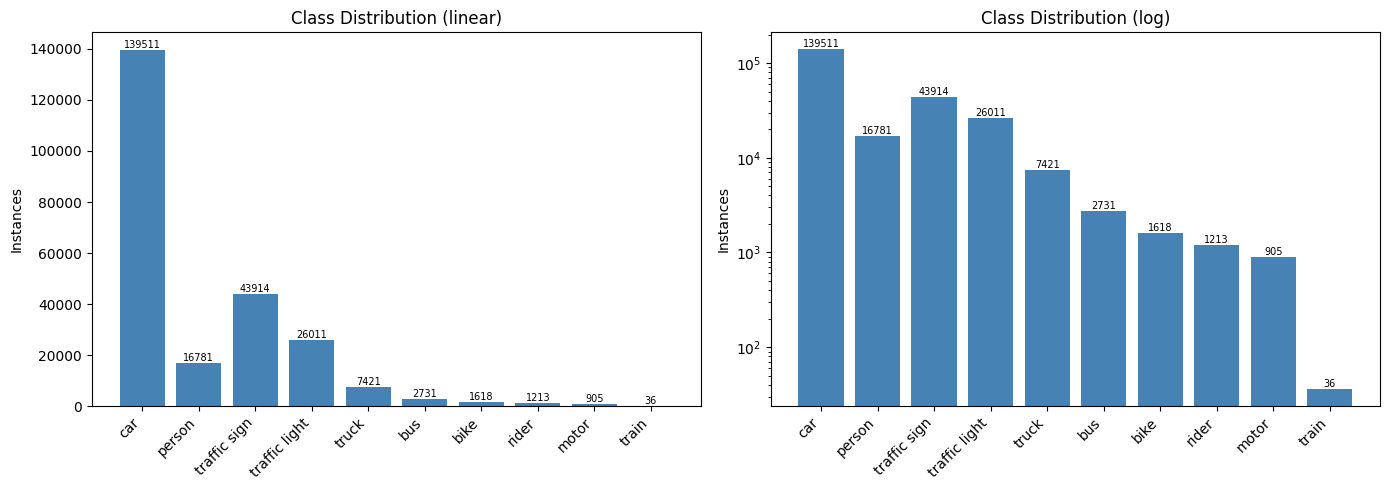

In [ ]:
train_boxes, train_obj_counts = load_labels("clear_day/train")
print(f"Total boxes: {len(train_boxes)}")

class_counts = Counter(int(c) for c in train_boxes[:, 0])
names = [CLASS_NAMES[i] for i in range(10)]
counts = [class_counts.get(i, 0) for i in range(10)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(names, counts, color="steelblue")
ax1.set_ylabel("Instances")
ax1.set_title("Class Distribution (linear)")
ax1.bar_label(ax1.containers[0], fmt="%d", fontsize=7)
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

ax2.bar(names, counts, color="steelblue")
ax2.set_ylabel("Instances")
ax2.set_title("Class Distribution (log)")
ax2.set_yscale("log")
ax2.bar_label(ax2.containers[0], fmt="%d", fontsize=7)
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Objects per image

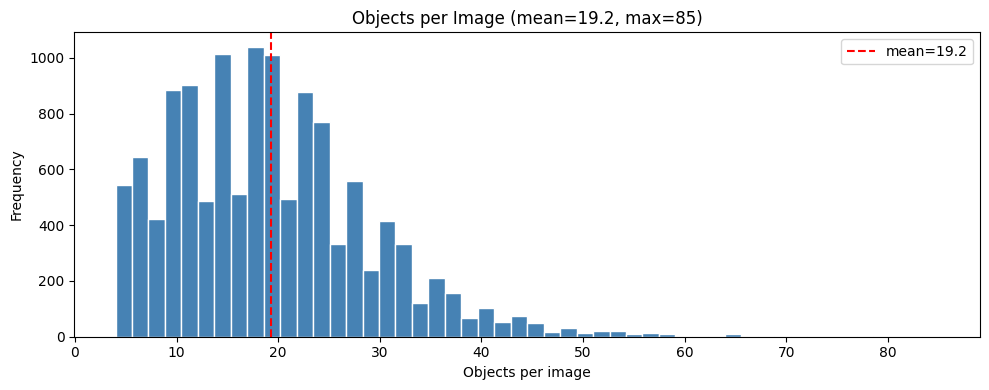

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_obj_counts, bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("Objects per image")
ax.set_ylabel("Frequency")
ax.set_title(f"Objects per Image (mean={np.mean(train_obj_counts):.1f}, max={max(train_obj_counts)})")
ax.axvline(np.mean(train_obj_counts), color="red", linestyle="--", label=f"mean={np.mean(train_obj_counts):.1f}")
ax.legend()
plt.tight_layout()
plt.show()

## Bounding box sizes

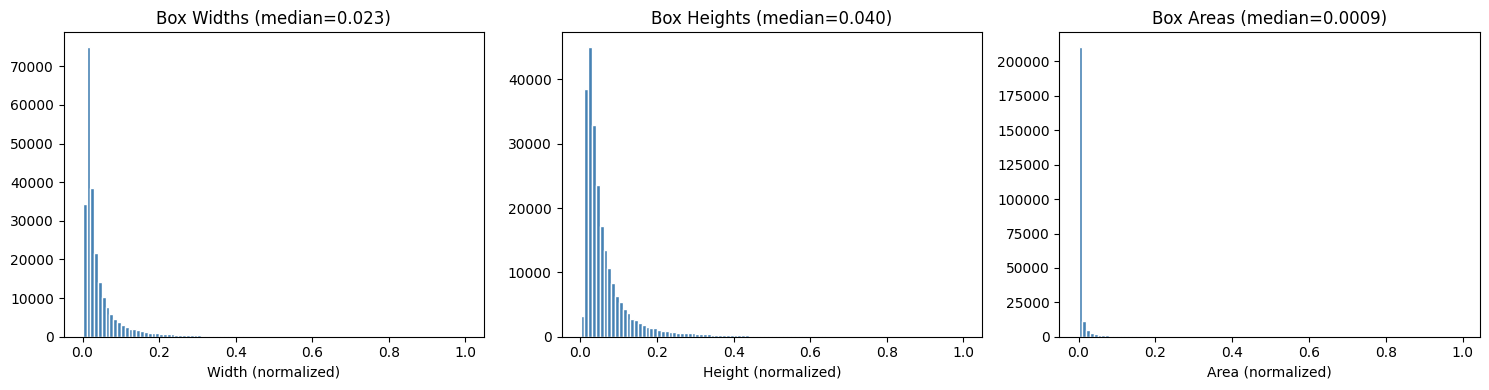

In [ ]:
widths = train_boxes[:, 3]
heights = train_boxes[:, 4]
areas = widths * heights

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=100, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Width (normalized)")
axes[0].set_title(f"Box Widths (median={np.median(widths):.3f})")

axes[1].hist(heights, bins=100, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Height (normalized)")
axes[1].set_title(f"Box Heights (median={np.median(heights):.3f})")

axes[2].hist(areas, bins=100, color="steelblue", edgecolor="white")
axes[2].set_xlabel("Area (normalized)")
axes[2].set_title(f"Box Areas (median={np.median(areas):.4f})")

plt.tight_layout()
plt.show()

## Box center heatmap

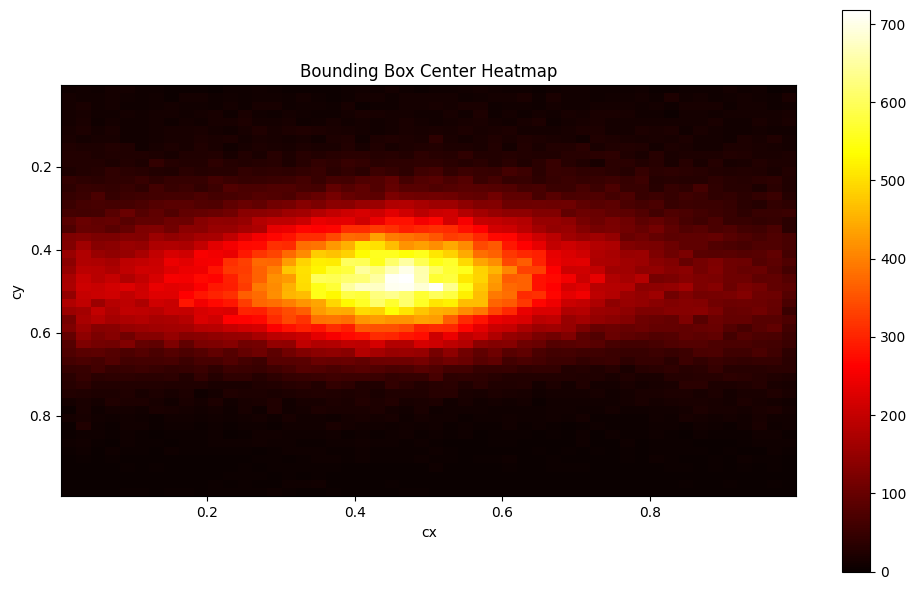

In [ ]:
cx = train_boxes[:, 1]
cy = train_boxes[:, 2]

fig, ax = plt.subplots(figsize=(10, 6))
h = ax.hist2d(cx, cy, bins=50, cmap="hot")
ax.set_xlabel("cx")
ax.set_ylabel("cy")
ax.set_title("Bounding Box Center Heatmap")
ax.invert_yaxis()
ax.set_aspect(720/1280)
plt.colorbar(h[3], ax=ax)
plt.tight_layout()
plt.show()

## Box size per class

/tmp/ipykernel_360454/362911070.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(class_areas.values(), labels=class_areas.keys(), showfliers=False)


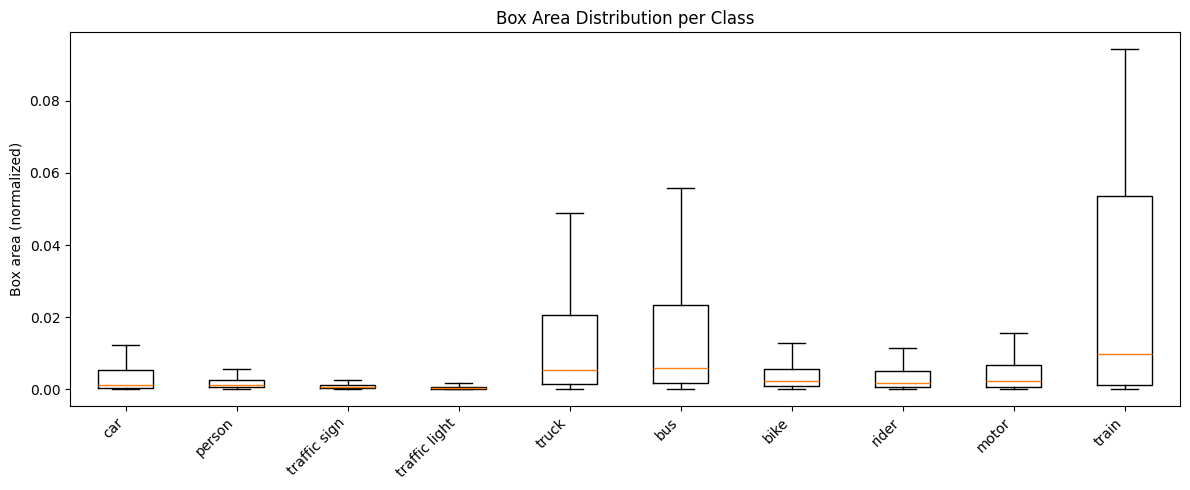

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

class_areas = {}
for i in range(10):
    mask = train_boxes[:, 0] == i
    if mask.sum() > 0:
        class_areas[CLASS_NAMES[i]] = train_boxes[mask, 3] * train_boxes[mask, 4]

ax.boxplot(class_areas.values(), labels=class_areas.keys(), showfliers=False)
ax.set_ylabel("Box area (normalized)")
ax.set_title("Box Area Distribution per Class")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Class distribution across splits

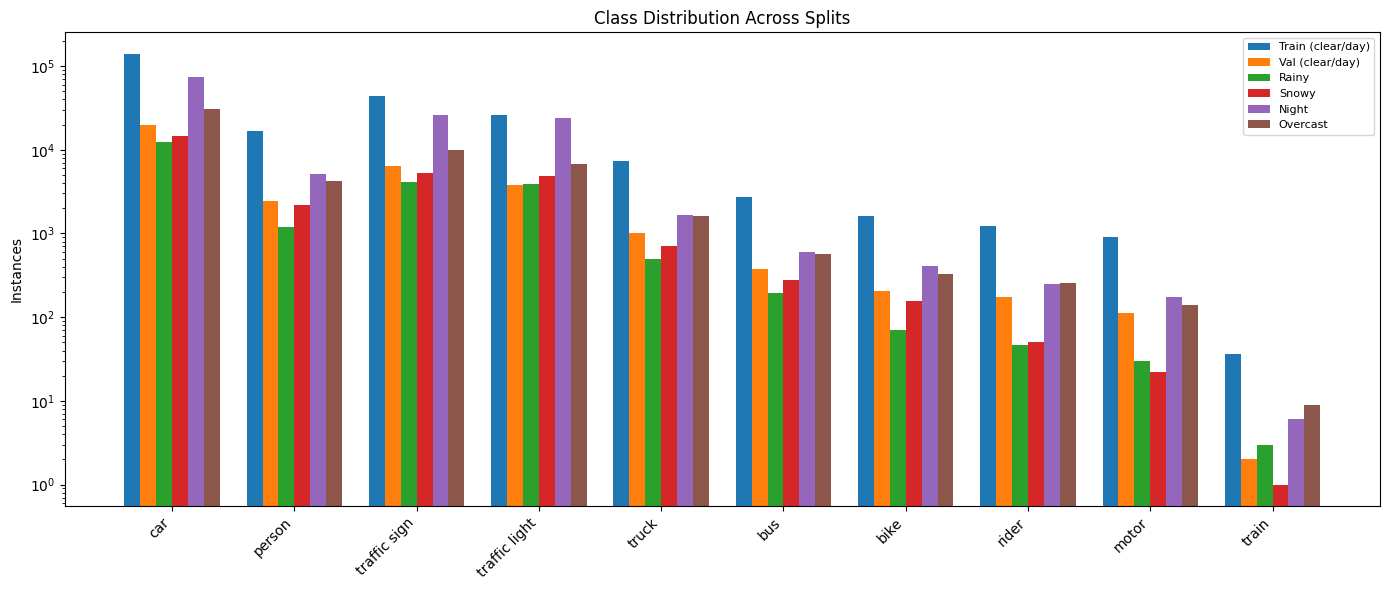

In [ ]:
split_class_counts = {}
for split, label in SPLITS.items():
    boxes, _ = load_labels(split)
    if len(boxes) > 0:
        counts = Counter(int(c) for c in boxes[:, 0])
        split_class_counts[label] = [counts.get(i, 0) for i in range(10)]
    else:
        split_class_counts[label] = [0] * 10

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(10)
width = 0.13

for i, (label, counts) in enumerate(split_class_counts.items()):
    ax.bar(x + i * width, counts, width, label=label)

ax.set_xticks(x + width * 2.5)
ax.set_xticklabels([CLASS_NAMES[i] for i in range(10)], rotation=45, ha="right")
ax.set_ylabel("Instances")
ax.set_yscale("log")
ax.set_title("Class Distribution Across Splits")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Sample images

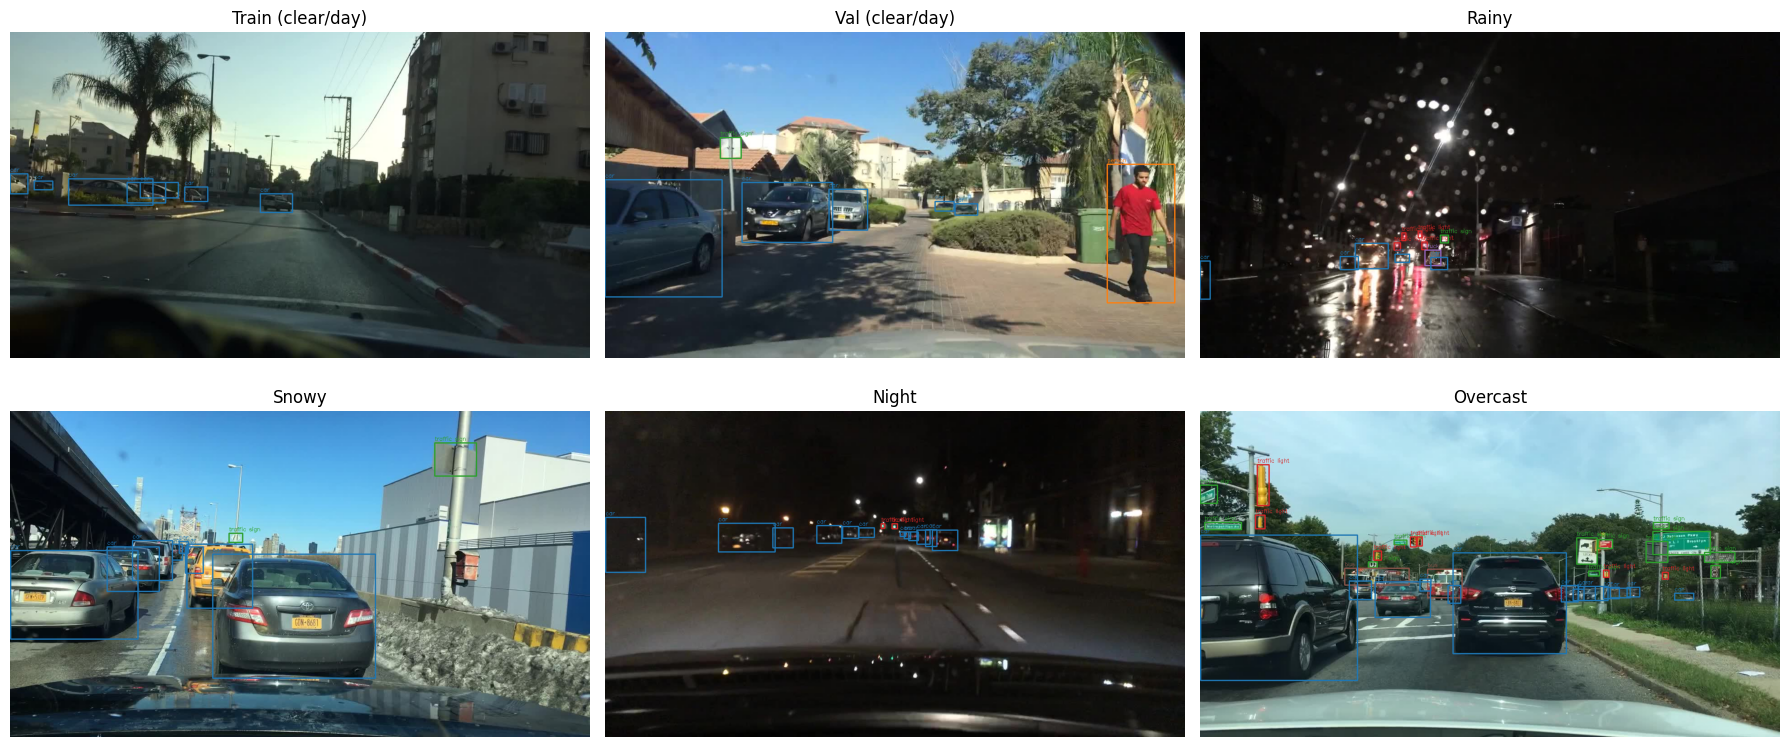

In [ ]:
COLORS = plt.cm.tab10(np.linspace(0, 1, 10))

def draw_boxes(img, label_path):
    h, w = img.shape[:2]
    for line in label_path.read_text().strip().splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        color = tuple(int(c * 255) for c in COLORS[cls][:3])
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img, CLASS_NAMES[cls], (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
    return img

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, (split, label) in zip(axes.flat, SPLITS.items()):
    img_dir = DATA / split / "images"
    lbl_dir = DATA / split / "labels"
    img_path = sorted(img_dir.glob("*.jpg"))[5]  # pick 6th image
    lbl_path = lbl_dir / (img_path.stem + ".txt")
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = draw_boxes(img, lbl_path)
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Aspect ratio distribution

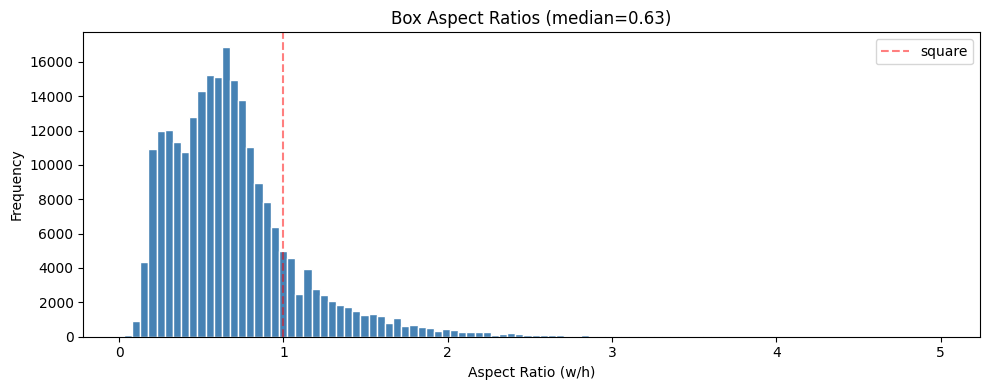

In [ ]:
aspect_ratios = widths / (heights + 1e-6)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(aspect_ratios[aspect_ratios < 5], bins=100, color="steelblue", edgecolor="white")
ax.set_xlabel("Aspect Ratio (w/h)")
ax.set_ylabel("Frequency")
ax.set_title(f"Box Aspect Ratios (median={np.median(aspect_ratios):.2f})")
ax.axvline(1.0, color="red", linestyle="--", alpha=0.5, label="square")
ax.legend()
plt.tight_layout()
plt.show()